# Mini-Project 1: Caltech-101 Image Classification (Baseline)

这个 notebook 是一个**基础可运行版本**，覆盖了作业要求的核心部分：

- 至少三种方法：
  - 传统机器学习：`HOG + LinearSVC`
  - 深度学习：`ResNet18 (transfer learning)`
  - 深度学习：`EfficientNet-B0 (transfer learning)`
- 统一评估指标：Accuracy、Per-class Accuracy、Confusion Matrix、Precision/Recall/F1（macro & weighted）、Top-5 Accuracy
- 小型 ablation：
  - `EfficientNet-B0`: baseline `image_size=64, aug=off` with controls `image_size=128, aug=off` and `image_size=64, aug=on`

> 首次运行前：请先把 Caltech-101 数据集下载并解压到本机，然后修改下面配置里的 `DATA_ROOT` 路径。

In [1]:
# ===== 0) Imports & Global Config =====
from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    top_k_accuracy_score,
)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

from skimage.feature import hog

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

warnings.filterwarnings("ignore")


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("torch:", torch.__version__)

# Dataset path is fixed on this machine.
IMAGE_ROOT = Path("/Users/chengjian/Desktop/caltech-101")


MAX_PER_CLASS = None   # e.g. set 40 for quick debug
BATCH_SIZE = 32
DL_EPOCHS = 3
NUM_WORKERS = 2

Using device: cuda
torch: 2.10.0+cu128


## 1) Data Preparation (70/15/15 Stratified)

In [2]:
from google.colab import drive
drive.mount("/content/drive")

# 1) 清掉本地旧数据
!rm -rf /content/caltech-101 /content/caltech-101.tar

# 2) 从Drive重新拷贝（tar优先）
# 如果你有tar：
!cp "/content/drive/MyDrive/caltech-101.tar" /content/
!mkdir -p /content/caltech-101
!tar --warning=no-unknown-keyword -xf /content/caltech-101.tar -C /content/caltech-101 --strip-components=1

# 3) 快速检查
!du -sh /content/caltech-101
!ls /content/caltech-101 | head

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
151M	/content/caltech-101
accordion
airplanes
anchor
ant
BACKGROUND_Google
barrel
bass
beaver
binocular
bonsai


In [3]:
from google.colab import drive
from pathlib import Path
import os

# 路径
DRIVE_TAR = "/content/drive/MyDrive/caltech-101.tar"
IMAGE_ROOT = Path("/content/caltech-101")

# 1) 彻底清理本地
os.system('rm -rf "/content/caltech-101" "/content/caltech-101.tar"')
os.system('mkdir -p "/content/caltech-101"')

# 2) 重新从 Drive tar 加载
os.system(f'cp "{DRIVE_TAR}" /content/caltech-101.tar')
os.system('tar --warning=no-unknown-keyword -xf /content/caltech-101.tar -C "/content/caltech-101" --strip-components=1')

# 3) 统计总图片数（只算常见图片后缀）
count_cmd = r'''find /content/caltech-101 -type f \( -iname "*.jpg" -o -iname "*.jpeg" -o -iname "*.png" -o -iname "*.bmp" -o -iname "*.gif" \) | wc -l'''
os.system('du -sh "/content/caltech-101"')
os.system(count_cmd)

print("IMAGE_ROOT =", IMAGE_ROOT)

# ===== 1) Build dataframe + stratified split =====
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def build_dataframe(image_root: Path, max_per_class=None) -> pd.DataFrame:
    rows = []
    class_dirs = sorted([d for d in image_root.iterdir() if d.is_dir()])

    for class_dir in class_dirs:
        class_name = class_dir.name
        if class_name.lower() in {"background_google", "__macosx"}:
            continue

        imgs = sorted([p for p in class_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS])
        if max_per_class is not None:
            imgs = imgs[:max_per_class]

        for p in imgs:
            rows.append({"path": str(p), "label_name": class_name})

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f"No images found under IMAGE_ROOT={image_root}")

    label_names = sorted(df["label_name"].unique())
    label2id = {n: i for i, n in enumerate(label_names)}
    df["label_id"] = df["label_name"].map(label2id)
    return df, label2id

if not IMAGE_ROOT.exists():
    raise FileNotFoundError(f"IMAGE_ROOT not found: {IMAGE_ROOT}")

full_df, label2id = build_dataframe(IMAGE_ROOT, max_per_class=MAX_PER_CLASS)
id2label = {v: k for k, v in label2id.items()}
num_classes = len(label2id)

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.30,
    random_state=42,
    stratify=full_df["label_id"],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label_id"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Image root: {IMAGE_ROOT}")
print(f"Total images: {len(full_df):,}")
print(f"Classes: {num_classes}")
print(f"Train/Val/Test = {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
train_df.head()

IMAGE_ROOT = /content/caltech-101
Image root: /content/caltech-101
Total images: 8,677
Classes: 101
Train/Val/Test = 6,073 / 1,302 / 1,302


,path,label_name,label_id
0,/content/caltech-101/Faces_easy/image_0360.jpg,Faces_easy,1
1,/content/caltech-101/water_lilly/image_0022.jpg,water_lilly,95
2,/content/caltech-101/joshua_tree/image_0062.jpg,joshua_tree,53
3,/content/caltech-101/Motorbikes/image_0657.jpg,Motorbikes,3
4,/content/caltech-101/umbrella/image_0035.jpg,umbrella,93


## 2) Unified Evaluation Metrics

In [ ]:
# ===== 2) Metrics helpers =====

def compute_metrics(y_true, y_pred, num_classes, y_prob=None, topk=5):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    per_class_acc = np.divide(
        cm.diagonal(),
        cm.sum(axis=1),
        out=np.zeros(num_classes, dtype=float),
        where=cm.sum(axis=1) != 0,
    )

    out = {
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f1_weighted,
        "per_class_accuracy_mean": float(np.mean(per_class_acc)),
        "confusion_matrix": cm,
        "per_class_accuracy": per_class_acc,
    }

    if y_prob is not None:
        k = min(topk, num_classes)
        out[f"top{k}_accuracy"] = top_k_accuracy_score(
            y_true,
            y_prob,
            k=k,
            labels=list(range(num_classes)),
        )

    return out


def plot_confusion_matrix(cm, title="Confusion Matrix", max_classes_to_show=25):
    cm_plot = cm
    if cm.shape[0] > max_classes_to_show:
        cm_plot = cm[:max_classes_to_show, :max_classes_to_show]
        title = f"{title} (first {max_classes_to_show} classes)"

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_plot, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def metrics_row(model_name, ablation, m):
    row = {
        "model": model_name,
        "ablation": ablation,
        "accuracy": m["accuracy"],
        "per_class_accuracy_mean": m["per_class_accuracy_mean"],
        "precision_macro": m["precision_macro"],
        "recall_macro": m["recall_macro"],
        "f1_macro": m["f1_macro"],
        "precision_weighted": m["precision_weighted"],
        "recall_weighted": m["recall_weighted"],
        "f1_weighted": m["f1_weighted"],
    }
    if "top5_accuracy" in m:
        row["top5_accuracy"] = m["top5_accuracy"]
    return row

## 3) Method A: HOG + LinearSVC (Classical ML)

Single setting: image size `64`

In [5]:
# ===== 3) HOG + SVM =====

# Unified fast settings
HOG_ORIENTATIONS = 6
HOG_PIXELS_PER_CELL = (32, 32)
HOG_CELLS_PER_BLOCK = (2, 2)


def extract_hog_features(
    paths,
    image_size=64,
    orientations=HOG_ORIENTATIONS,
    pixels_per_cell=HOG_PIXELS_PER_CELL,
    cells_per_block=HOG_CELLS_PER_BLOCK,
):
    feats = []
    for p in tqdm(paths, desc=f"HOG {image_size}x{image_size}"):
        img = Image.open(p).convert("L").resize((image_size, image_size))
        arr = np.asarray(img, dtype=np.float32)
        feat = hog(
            arr,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm="L2-Hys",
            feature_vector=True,
        )
        feats.append(feat)
    return np.asarray(feats, dtype=np.float32)


def run_hog_svm(train_df, test_df, image_size=64):
    X_train = extract_hog_features(train_df["path"].tolist(), image_size=image_size)
    y_train = train_df["label_id"].values

    X_test = extract_hog_features(test_df["path"].tolist(), image_size=image_size)
    y_test = test_df["label_id"].values

    clf = make_pipeline(
        StandardScaler(),
        LinearSVC(
            verbose=0,
            max_iter=1000,
            tol=2e-3,
            dual="auto",
            random_state=42,
        ),
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # LinearSVC has no predict_proba; use decision scores for top-k ranking.
    y_score = clf.decision_function(X_test)

    m = compute_metrics(y_test, y_pred, num_classes=num_classes, y_prob=y_score)
    return m

HOG 64x64:   0%|          | 0/6073 [00:00<?, ?it/s]

HOG 64x64:   0%|          | 0/1302 [00:00<?, ?it/s]

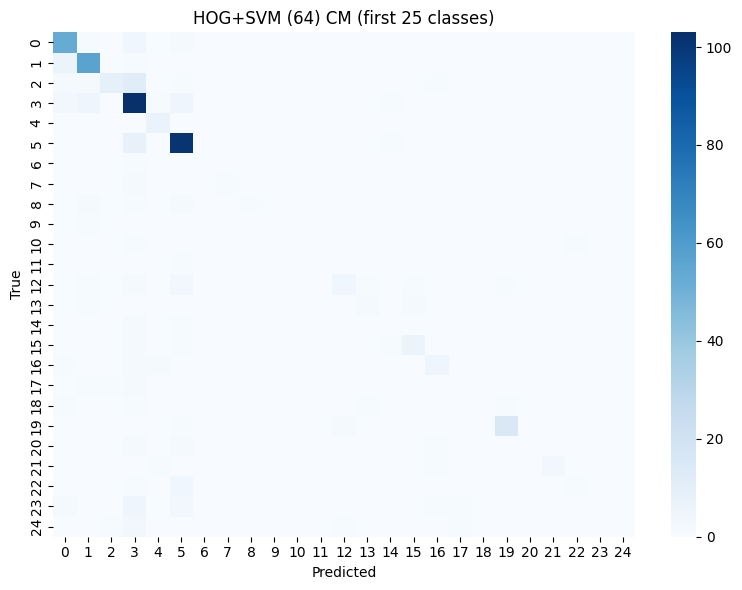

,model,ablation,accuracy,per_class_accuracy_mean,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top5_accuracy
0,HOG+LinearSVC,image_size=64,0.412442,0.226735,0.2106,0.226735,0.200938,0.30799,0.412442,0.336607,0.644393


In [ ]:
# ===== 3A) Run HOG + LinearSVC (64 only) =====
all_rows = []

hog_metrics_64 = run_hog_svm(train_df, test_df, image_size=64)
all_rows.append(metrics_row("HOG+LinearSVC", "image_size=64", hog_metrics_64))

plot_confusion_matrix(hog_metrics_64["confusion_matrix"], title="HOG+SVM (64) CM")
pd.DataFrame(all_rows)

## 4) Method B/C: Transfer Learning (ResNet18 & EfficientNet-B0)

Ablation: EfficientNet-B0 baseline `image_size=64, aug=off` with controls `image_size=128, aug=off` and `image_size=64, aug=on`

In [7]:
# ===== 4) Deep learning pipelines =====
class ImageClsDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        y = int(row["label_id"])
        if self.transform:
            img = self.transform(img)
        return img, y


def make_transforms(image_size=64, use_aug=True):
    if use_aug:
        train_tfms = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
        ])
    else:
        train_tfms = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    eval_tfms = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])
    return train_tfms, eval_tfms


def make_loaders(train_df, val_df, test_df, image_size=64, use_aug=True, batch_size=32):
    train_tfms, eval_tfms = make_transforms(image_size=image_size, use_aug=use_aug)
    train_ds = ImageClsDataset(train_df, transform=train_tfms)
    val_ds = ImageClsDataset(val_df, transform=eval_tfms)
    test_ds = ImageClsDataset(test_df, transform=eval_tfms)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader


def build_model(model_name: str, num_classes: int, train_head_only: bool = True):
    if model_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        head_params = model.fc.parameters()
    elif model_name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        head_params = model.classifier.parameters()
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    if train_head_only:
        for p in model.parameters():
            p.requires_grad = False
        for p in head_params:
            p.requires_grad = True

    return model.to(device)


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def predict_with_probs(model, loader):
    model.eval()
    y_true, y_pred, y_prob = [], [], []

    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)
        pred = prob.argmax(dim=1)

        y_true.append(y.numpy())
        y_pred.append(pred.cpu().numpy())
        y_prob.append(prob.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)
    return y_true, y_pred, y_prob


def run_dl_experiment(
    model_name,
    train_df,
    val_df,
    test_df,
    image_size=64,
    use_aug=True,
    optimizer_name="adam",
    lr=1e-3,
    epochs=3,
    train_head_only=True,
):
    train_loader, val_loader, test_loader = make_loaders(
        train_df, val_df, test_df,
        image_size=image_size,
        use_aug=use_aug,
        batch_size=BATCH_SIZE,
    )

    model = build_model(model_name, num_classes=num_classes, train_head_only=train_head_only)
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]

    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(trainable_params, lr=lr)
    elif optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(trainable_params, lr=lr, momentum=0.9)
    else:
        raise ValueError("optimizer_name must be 'adam' or 'sgd'")

    history = []
    best_val_acc = -1
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = eval_epoch(model, val_loader, criterion)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        print(
            f"[{model_name}] epoch {epoch}/{epochs} | "
            f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    y_true, y_pred, y_prob = predict_with_probs(model, test_loader)
    metrics = compute_metrics(y_true, y_pred, num_classes=num_classes, y_prob=y_prob, topk=5)
    history_df = pd.DataFrame(history)

    return metrics, history_df

[resnet18] epoch 1/3 | train_acc=0.4976, val_acc=0.5952
[resnet18] epoch 2/3 | train_acc=0.6957, val_acc=0.6667
[resnet18] epoch 3/3 | train_acc=0.8134, val_acc=0.6928


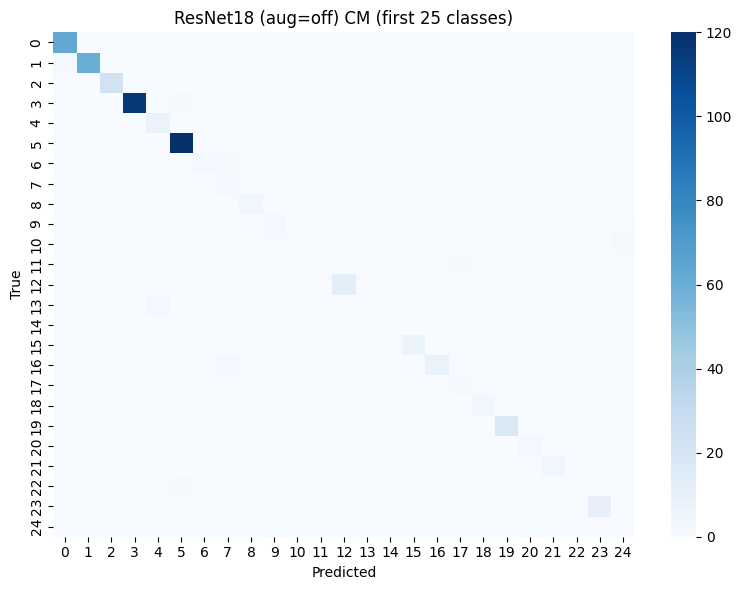

,model,ablation,accuracy,per_class_accuracy_mean,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top5_accuracy
0,HOG+LinearSVC,image_size=64,0.412442,0.226735,0.210600,0.226735,0.200938,0.307990,0.412442,0.336607,0.644393
1,ResNet18,aug=off,0.674347,0.540283,0.601081,0.540283,0.518616,0.730064,0.674347,0.664920,0.865591


In [ ]:
# ===== 5A) Run ResNet18 (aug=off) =====
if "all_rows" not in globals():
    all_rows = []

resnet_no_aug_m, resnet_no_aug_hist = run_dl_experiment(
    model_name="resnet18",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    image_size=64,
    use_aug=False,
    optimizer_name="adam",
    lr=1e-3,
    epochs=DL_EPOCHS,
    train_head_only=False,
)
all_rows.append(metrics_row("ResNet18", "aug=off", resnet_no_aug_m))

plot_confusion_matrix(resnet_no_aug_m["confusion_matrix"], title="ResNet18 (aug=off) CM")
pd.DataFrame(all_rows)

[efficientnet_b0] epoch 1/3 | train_acc=0.5085, val_acc=0.6767
[efficientnet_b0] epoch 2/3 | train_acc=0.7295, val_acc=0.7765
[efficientnet_b0] epoch 3/3 | train_acc=0.8421, val_acc=0.7903


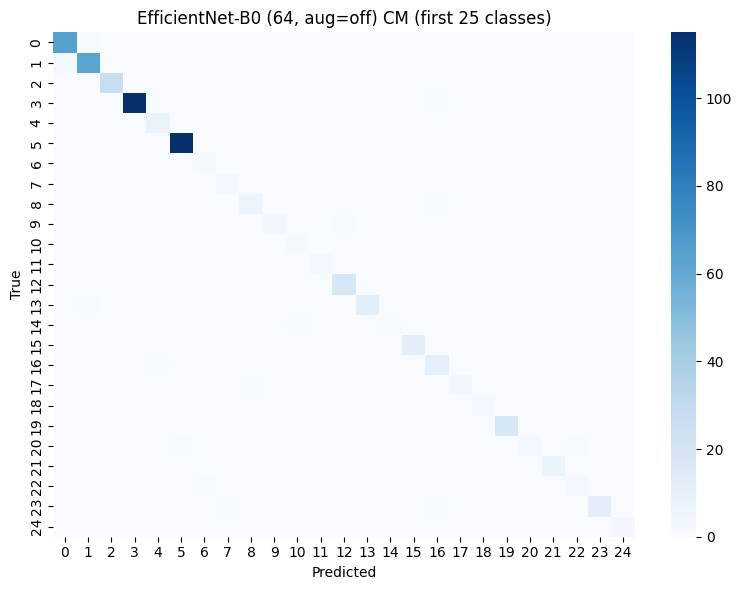

,model,ablation,accuracy,per_class_accuracy_mean,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top5_accuracy
0,HOG+LinearSVC,image_size=64,0.412442,0.226735,0.210600,0.226735,0.200938,0.307990,0.412442,0.336607,0.644393
1,ResNet18,aug=off,0.674347,0.540283,0.601081,0.540283,0.518616,0.730064,0.674347,0.664920,0.865591
2,EfficientNet-B0,"image_size=64,aug=off",0.783410,0.685924,0.696378,0.685924,0.675646,0.798317,0.783410,0.779645,0.933180


In [ ]:
# ===== 5C-1) EfficientNet-B0 baseline: image_size=64, aug=off =====
if "all_rows" not in globals():
    all_rows = []


effb0_base_m, effb0_base_hist = run_dl_experiment(
    model_name="efficientnet_b0",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    image_size=64,
    use_aug=False,
    optimizer_name="adam",
    lr=1e-3,
    epochs=DL_EPOCHS,
    train_head_only=False,
)
all_rows.append(metrics_row("EfficientNet-B0", "image_size=64,aug=off", effb0_base_m))

plot_confusion_matrix(effb0_base_m["confusion_matrix"], title="EfficientNet-B0 (64, aug=off) CM")
pd.DataFrame(all_rows)

[efficientnet_b0] epoch 1/3 | train_acc=0.6845, val_acc=0.8571
[efficientnet_b0] epoch 2/3 | train_acc=0.8844, val_acc=0.8748
[efficientnet_b0] epoch 3/3 | train_acc=0.9366, val_acc=0.9025


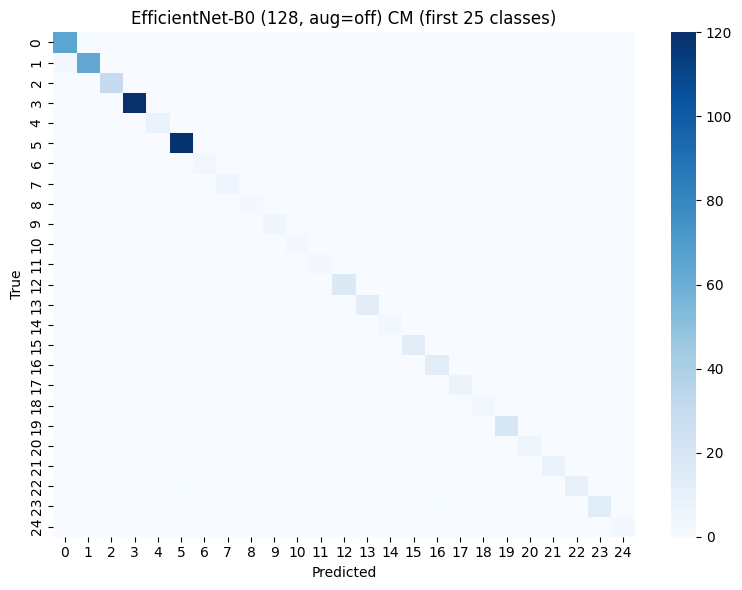

,model,ablation,accuracy,per_class_accuracy_mean,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top5_accuracy
0,HOG+LinearSVC,image_size=64,0.412442,0.226735,0.210600,0.226735,0.200938,0.307990,0.412442,0.336607,0.644393
1,ResNet18,aug=off,0.674347,0.540283,0.601081,0.540283,0.518616,0.730064,0.674347,0.664920,0.865591
2,EfficientNet-B0,"image_size=64,aug=off",0.783410,0.685924,0.696378,0.685924,0.675646,0.798317,0.783410,0.779645,0.933180
3,EfficientNet-B0,"image_size=128,aug=off",0.899386,0.858292,0.874934,0.858292,0.853127,0.913329,0.899386,0.897720,0.978495


In [ ]:
# ===== 5C-2) EfficientNet-B0 control: image_size=128, aug=off =====
effb0_size_m, effb0_size_hist = run_dl_experiment(
    model_name="efficientnet_b0",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    image_size=128,
    use_aug=False,
    optimizer_name="adam",
    lr=1e-3,
    epochs=DL_EPOCHS,
    train_head_only=False,
)
all_rows.append(metrics_row("EfficientNet-B0", "image_size=128,aug=off", effb0_size_m))

plot_confusion_matrix(effb0_size_m["confusion_matrix"], title="EfficientNet-B0 (128, aug=off) CM")
pd.DataFrame(all_rows)

[efficientnet_b0] epoch 1/3 | train_acc=0.4556, val_acc=0.6283
[efficientnet_b0] epoch 2/3 | train_acc=0.6791, val_acc=0.7512
[efficientnet_b0] epoch 3/3 | train_acc=0.7863, val_acc=0.7811


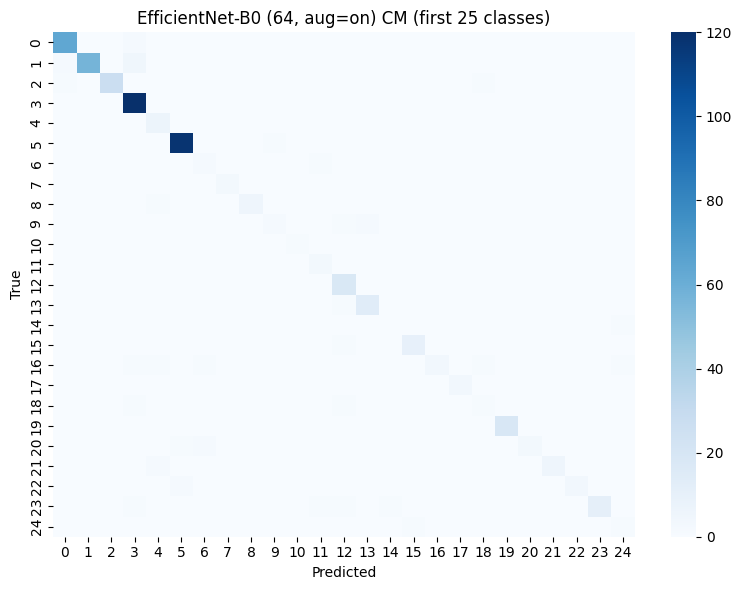

,model,ablation,accuracy,per_class_accuracy_mean,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top5_accuracy
0,HOG+LinearSVC,image_size=64,0.412442,0.226735,0.210600,0.226735,0.200938,0.307990,0.412442,0.336607,0.644393
1,ResNet18,aug=off,0.674347,0.540283,0.601081,0.540283,0.518616,0.730064,0.674347,0.664920,0.865591
2,EfficientNet-B0,"image_size=64,aug=off",0.783410,0.685924,0.696378,0.685924,0.675646,0.798317,0.783410,0.779645,0.933180
3,EfficientNet-B0,"image_size=128,aug=off",0.899386,0.858292,0.874934,0.858292,0.853127,0.913329,0.899386,0.897720,0.978495
4,EfficientNet-B0,"image_size=64,aug=on",0.769585,0.659212,0.705875,0.659212,0.654726,0.787625,0.769585,0.760589,0.925499


In [ ]:
# ===== 5C-3) EfficientNet-B0 control: image_size=64, aug=on =====
effb0_aug_m, effb0_aug_hist = run_dl_experiment(
    model_name="efficientnet_b0",
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    image_size=64,
    use_aug=True,
    optimizer_name="adam",
    lr=1e-3,
    epochs=DL_EPOCHS,
    train_head_only=False,
)
all_rows.append(metrics_row("EfficientNet-B0", "image_size=64,aug=on", effb0_aug_m))

plot_confusion_matrix(effb0_aug_m["confusion_matrix"], title="EfficientNet-B0 (64, aug=on) CM")
pd.DataFrame(all_rows)

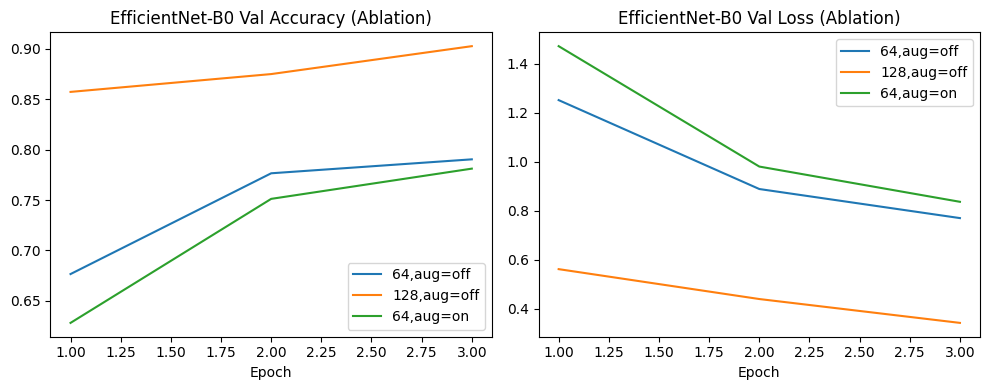

,model,ablation,accuracy,per_class_accuracy_mean,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,top5_accuracy
0,HOG+LinearSVC,image_size=64,0.412442,0.226735,0.210600,0.226735,0.200938,0.307990,0.412442,0.336607,0.644393
1,ResNet18,aug=off,0.674347,0.540283,0.601081,0.540283,0.518616,0.730064,0.674347,0.664920,0.865591
2,EfficientNet-B0,"image_size=64,aug=off",0.783410,0.685924,0.696378,0.685924,0.675646,0.798317,0.783410,0.779645,0.933180
3,EfficientNet-B0,"image_size=128,aug=off",0.899386,0.858292,0.874934,0.858292,0.853127,0.913329,0.899386,0.897720,0.978495
4,EfficientNet-B0,"image_size=64,aug=on",0.769585,0.659212,0.705875,0.659212,0.654726,0.787625,0.769585,0.760589,0.925499


In [ ]:
# ===== 5C-4) EfficientNet-B0 ablation curves =====
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(effb0_base_hist["epoch"], effb0_base_hist["val_acc"], label="64,aug=off")
axes[0].plot(effb0_size_hist["epoch"], effb0_size_hist["val_acc"], label="128,aug=off")
axes[0].plot(effb0_aug_hist["epoch"], effb0_aug_hist["val_acc"], label="64,aug=on")
axes[0].set_title("EfficientNet-B0 Val Accuracy (Ablation)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(effb0_base_hist["epoch"], effb0_base_hist["val_loss"], label="64,aug=off")
axes[1].plot(effb0_size_hist["epoch"], effb0_size_hist["val_loss"], label="128,aug=off")
axes[1].plot(effb0_aug_hist["epoch"], effb0_aug_hist["val_loss"], label="64,aug=on")
axes[1].set_title("EfficientNet-B0 Val Loss (Ablation)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

pd.DataFrame(all_rows)

## 5) Final Comparison Table + Report Notes

In [13]:
# ===== 6) Final results table =====
results_df = pd.DataFrame(all_rows)

sort_cols = ["accuracy", "f1_macro", "per_class_accuracy_mean"]
results_df = results_df.sort_values(by=sort_cols, ascending=False).reset_index(drop=True)

display_cols = [
    "model", "ablation",
    "accuracy", "top5_accuracy",
    "per_class_accuracy_mean",
    "precision_macro", "recall_macro", "f1_macro",
    "precision_weighted", "recall_weighted", "f1_weighted",
]

for c in display_cols:
    if c not in results_df.columns:
        results_df[c] = np.nan

results_df[display_cols]

# Optional: save for your report
# results_df.to_csv("mini_proj1_results.csv", index=False)

print("\nReport checklist:")
print("1) Methods: HOG+SVM, ResNet18, EfficientNet-B0")
print("2) Metrics: accuracy / per-class acc / confusion matrix / precision-recall-f1 / top-5")
print("3) Ablation: EfficientNet-B0 baseline(64, off), control(128, off), control(64, on)")
print("4) Add your observations and interpretations in markdown cells below.")


Report checklist:
1) Methods: HOG+SVM, ResNet18, EfficientNet-B0
2) Metrics: accuracy / per-class acc / confusion matrix / precision-recall-f1 / top-5
3) Ablation: EfficientNet-B0 baseline(64, off), control(128, off), control(64, on)
4) Add your observations and interpretations in markdown cells below.
